# 🧠 RL-Based Intelligent University Timetable Scheduler
### CT-469 Reinforcement Learning — Course Project

**System:** GA (initial population) → DQN (local refinement) → Constraint Propagation (validation)  
**Baselines:** Manual (random) | Greedy | GA-only | RL-Hybrid  
**Scale:** 1200 students · 30 courses · 12 rooms · 30 time slots

---

## Cell 1 — Install Dependencies

In [1]:
!pip -q install gradio torch numpy pandas matplotlib seaborn


## Cell 2 — Google Drive Mount & Checkpoint Setup

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_DIR           = '/content/drive/MyDrive/RL_Timetable'
CHECKPOINT_DIR      = os.path.join(DRIVE_DIR, 'checkpoints')
RESULTS_DIR         = os.path.join(DRIVE_DIR, 'results')
MODEL_PATH          = os.path.join(DRIVE_DIR, 'best_model.pth')
FINAL_SCHEDULE_PATH = os.path.join(DRIVE_DIR, 'final_schedule.csv')
METRICS_PATH        = os.path.join(DRIVE_DIR, 'training_metrics.csv')

for d in [DRIVE_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)


Mounted at /content/drive


## Cell 3 — Imports & Reproducibility

In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import copy
import json
import time
from collections import deque, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import gradio as gr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## Cell 4 — Data Setup (1200 students, 12 rooms, 30 courses)

In [4]:
DAYS  = ["Mon", "Tue", "Wed", "Thu", "Fri"]
HOURS = ["09:00", "10:00", "11:00", "12:00", "14:00", "15:00"]
TIME_SLOTS = [f"{d}-{h}" for d in DAYS for h in HOURS]  # 30 slots

EVENING_SLOTS = {s for s in TIME_SLOTS if "15:00" in s}

ROOMS = {
    "R1":  60,  "R2":  80,  "R3": 100, "R4": 120,
    "R5": 150,  "R6": 200,  "R7":  70, "R8":  90,
    "R9": 110,  "R10":130,  "R11":160, "R12":220
}

TEACHERS = [f"T{i}" for i in range(1, 13)]
COURSES   = [f"C{i}" for i in range(1, 31)]

NUM_STUDENTS = 1200
STUDENTS = [f"S{i}" for i in range(1, NUM_STUDENTS + 1)]

# Teacher preferences: preferred time slots (soft constraint)
TEACHER_PREFS = {
    t: random.sample(TIME_SLOTS, k=random.randint(4, 8))
    for t in TEACHERS
}

random.seed(SEED)
course_data = {}
for c in COURSES:
    teacher = random.choice(TEACHERS)
    n = random.randint(35, 160)
    course_data[c] = {
        "teacher": teacher,
        "students": random.sample(STUDENTS, n),
        "size": n
    }


## Cell 5 — Constraint Evaluation (Hard + Soft, MDP-aligned)

In [5]:
# Hard constraints (must not be violated)
PENALTY_ROOM_OVERFLOW   = 100
PENALTY_TEACHER_CLASH   = 200
PENALTY_ROOM_CLASH      = 200
PENALTY_STUDENT_CLASH   =  20

# Soft constraints (preferred)
PENALTY_3_CLASSES_DAY   =  10
PENALTY_EVENING         =   5
PENALTY_TEACHER_PREF    =   8

REWARD_VALID_SCHEDULE   = 1000

def evaluate_schedule(schedule, detailed=False):
    """
    Returns (total_penalty, breakdown_dict) if detailed=True,
    else just total_penalty (int).
    """
    hard = 0
    soft = 0
    breakdown = defaultdict(int)

    teacher_slots = defaultdict(list)
    room_slots    = defaultdict(list)
    student_slots = defaultdict(list)
    student_days  = defaultdict(lambda: defaultdict(int))

    for c, a in schedule.items():
        slot  = a["slot"]
        room  = a["room"]
        day   = slot.split("-")[0]
        teacher = course_data[c]["teacher"]
        size    = course_data[c]["size"]

        if size > ROOMS[room]:
            p = PENALTY_ROOM_OVERFLOW
            hard += p
            breakdown["room_overflow"] += p

        if slot in teacher_slots[teacher]:
            p = PENALTY_TEACHER_CLASH
            hard += p
            breakdown["teacher_clash"] += p
        teacher_slots[teacher].append(slot)

        key = (room, slot)
        if key in room_slots:
            p = PENALTY_ROOM_CLASH
            hard += p
            breakdown["room_clash"] += p
        room_slots[key] = c

        for s in course_data[c]["students"]:
            if slot in student_slots[s]:
                p = PENALTY_STUDENT_CLASH
                hard += p
                breakdown["student_clash"] += p
            student_slots[s].append(slot)
            student_days[s][day] += 1

        if slot in EVENING_SLOTS:
            p = PENALTY_EVENING
            soft += p
            breakdown["evening_penalty"] += p

        if slot not in TEACHER_PREFS[teacher]:
            p = PENALTY_TEACHER_PREF
            soft += p
            breakdown["teacher_pref"] += p

    for s, days in student_days.items():
        for day, cnt in days.items():
            if cnt >= 3:
                p = PENALTY_3_CLASSES_DAY * (cnt - 2)
                soft += p
                breakdown["overloaded_day"] += p

    total = hard + soft
    breakdown["hard_total"] = hard
    breakdown["soft_total"] = soft
    breakdown["total"] = total

    if detailed:
        return total, dict(breakdown)
    return total

def count_hard_violations(schedule):
    """Count number of hard constraint violations (not penalty weight)."""
    v = 0
    teacher_slots = defaultdict(set)
    room_slots    = defaultdict(set)
    student_slots = defaultdict(set)

    for c, a in schedule.items():
        slot, room = a["slot"], a["room"]
        teacher = course_data[c]["teacher"]

        if course_data[c]["size"] > ROOMS[room]:  v += 1
        if slot in teacher_slots[teacher]:          v += 1
        teacher_slots[teacher].add(slot)
        if slot in room_slots[room]:                v += 1
        room_slots[room].add(slot)
        for s in course_data[c]["students"]:
            if slot in student_slots[s]:            v += 1
            student_slots[s].add(slot)
    return v



## Cell 6 — Baseline 1: Manual (Random) Scheduler

In [6]:
def manual_scheduler():
    schedule = {}
    for c in COURSES:
        schedule[c] = {
            "slot": random.choice(TIME_SLOTS),
            "room": random.choice(list(ROOMS.keys()))
        }
    return schedule


## Cell 7 — Baseline 2: Greedy Scheduler

In [7]:
def greedy_scheduler():
    schedule = {}
    for c in COURSES:
        best_a, best_p = None, float('inf')

        valid_rooms = [r for r, cap in ROOMS.items() if cap >= course_data[c]["size"]]
        if not valid_rooms:
            valid_rooms = list(ROOMS.keys())
        for slot in TIME_SLOTS:
            for room in valid_rooms:
                temp = copy.copy(schedule)
                temp[c] = {"slot": slot, "room": room}
                p = evaluate_schedule(temp)
                if p < best_p:
                    best_p = p
                    best_a = {"slot": slot, "room": room}
        schedule[c] = best_a
    return schedule


## Cell 8 — Baseline 3: Genetic Algorithm Scheduler

In [8]:
def ga_random_schedule():
    return {
        c: {
            "slot": random.choice(TIME_SLOTS),
            "room": random.choice(list(ROOMS.keys()))
        }
        for c in COURSES
    }

def ga_crossover(p1, p2):
    point = random.randint(1, len(COURSES) - 1)
    child = {}
    for i, c in enumerate(COURSES):
        child[c] = copy.copy(p1[c] if i < point else p2[c])
    return child

def ga_mutate(schedule, mutation_rate=0.1):
    mutated = copy.deepcopy(schedule)
    for c in COURSES:
        if random.random() < mutation_rate:
            if random.random() < 0.5:
                mutated[c]["slot"] = random.choice(TIME_SLOTS)
            else:
                mutated[c]["room"] = random.choice(list(ROOMS.keys()))
    return mutated

def ga_scheduler(
    pop_size=50,
    generations=80,
    mutation_rate=0.08,
    elite_frac=0.1,
    verbose=True
):
    population = [ga_random_schedule() for _ in range(pop_size)]
    elite_n    = max(1, int(pop_size * elite_frac))
    history    = []

    for gen in range(generations):
        scored = [(evaluate_schedule(s), s) for s in population]
        scored.sort(key=lambda x: x[0])

        best_p = scored[0][0]
        history.append(best_p)

        if verbose and gen % 20 == 0:
            print(f"  GA Gen {gen:3d} | Best penalty: {best_p}")

        elites = [s for _, s in scored[:elite_n]]

        penalties = np.array([p for p, _ in scored], dtype=float)
        max_p     = penalties.max() + 1
        fitness   = max_p - penalties
        weights   = fitness / fitness.sum()

        parents    = [s for _, s in scored]
        new_pop    = list(elites)
        while len(new_pop) < pop_size:
            p1, p2 = random.choices(parents, weights=weights, k=2)
            child  = ga_crossover(p1, p2)
            child  = ga_mutate(child, mutation_rate)
            new_pop.append(child)

        population = new_pop

    scored = [(evaluate_schedule(s), s) for s in population]
    scored.sort(key=lambda x: x[0])
    best_schedule = scored[0][1]

    if verbose:
        print(f"  GA Done | Final best penalty: {scored[0][0]}")

    return best_schedule, history



## Cell 9 — RL Environment (MDP)

In [9]:
class TimetableEnv:
    def __init__(self, init_schedule, max_steps=60):
        self.base_schedule = copy.deepcopy(init_schedule)
        self.max_steps = max_steps

        self.course_list = COURSES
        self.slot_list   = TIME_SLOTS
        self.room_list   = list(ROOMS.keys())

        self.n_courses = len(self.course_list)
        self.n_slots   = len(self.slot_list)
        self.n_rooms   = len(self.room_list)
        self.n_actions = self.n_courses * self.n_slots * self.n_rooms

        self.reset()

    def reset(self):
        self.schedule    = copy.deepcopy(self.base_schedule)
        self.step_n      = 0
        self.best_penalty = evaluate_schedule(self.schedule)
        self.best_schedule = copy.deepcopy(self.schedule)
        return self._get_state()

    def _get_state(self):
        cur_penalty   = evaluate_schedule(self.schedule)
        hard_viol     = count_hard_violations(self.schedule)
        return np.array([
            cur_penalty   / 10000.0,
            hard_viol     / 1000.0,
            self.step_n   / self.max_steps,
            self.best_penalty / 10000.0
        ], dtype=np.float32)

    def decode_action(self, action_idx):
        """Map flat action index → (course, slot, room)."""
        ci = action_idx // (self.n_slots * self.n_rooms)
        remainder = action_idx % (self.n_slots * self.n_rooms)
        si = remainder // self.n_rooms
        ri = remainder % self.n_rooms
        return self.course_list[ci], self.slot_list[si], self.room_list[ri]

    def step(self, action_idx):
        old_penalty = evaluate_schedule(self.schedule)

        course, slot, room = self.decode_action(action_idx)
        self.schedule[course] = {"slot": slot, "room": room}

        new_penalty = evaluate_schedule(self.schedule)

        delta  = old_penalty - new_penalty
        reward = np.clip(delta / 100.0, -1.0, 1.0)

        if count_hard_violations(self.schedule) == 0:
            reward += 2.0

        if new_penalty < self.best_penalty:
            self.best_penalty  = new_penalty
            self.best_schedule = copy.deepcopy(self.schedule)

        self.step_n += 1
        done = self.step_n >= self.max_steps

        return self._get_state(), reward, done

print(f"   Action space size: {len(COURSES)} courses × {len(TIME_SLOTS)} slots × {len(ROOMS)} rooms = {len(COURSES)*len(TIME_SLOTS)*len(ROOMS)} actions")

   Action space size: 30 courses × 30 slots × 12 rooms = 10800 actions


## Cell 10 — DQN Model & Replay Buffer

In [10]:
class DuelingDQN(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=256):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
        )
        self.value_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.adv_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        feat = self.shared(x)
        V = self.value_head(feat)
        A = self.adv_head(feat)
        Q    = V + (A - A.mean(dim=1, keepdim=True))
        return Q

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, ns, done):
        self.buf.append((s, a, r, ns, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            torch.tensor(np.array(s),  dtype=torch.float32),
            torch.tensor(a,            dtype=torch.long),
            torch.tensor(r,            dtype=torch.float32),
            torch.tensor(np.array(ns), dtype=torch.float32),
            torch.tensor(d,            dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buf)



## Cell 11 — Training Loop (with Drive checkpoints every 10 episodes)

In [11]:
def train_dqn(
    env,
    episodes       = 100,
    verbose        = True,
    batch_size     = 128,
    gamma          = 0.95,
    lr             = 3e-4,
    eps_start      = 1.0,
    eps_end        = 0.05,
    eps_decay      = 0.97,
    target_update  = 5,
    checkpoint_every = 10,
):
    state_dim = 4
    n_actions = env.n_actions

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model  = DuelingDQN(state_dim, n_actions).to(device)
    target = DuelingDQN(state_dim, n_actions).to(device)
    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss()
    buffer    = ReplayBuffer(capacity=15000)

    eps = eps_start
    metrics = {
        "episode":          [],
        "penalty":          [],
        "hard_violations":  [],
        "reward_sum":       [],
        "epsilon":          [],
        "loss":             [],
    }

    global_best_penalty  = evaluate_schedule(env.base_schedule)
    global_best_schedule = copy.deepcopy(env.base_schedule)

    for ep in range(1, episodes + 1):
        state     = env.reset()
        ep_reward = 0.0
        ep_loss   = []

        for _ in range(env.max_steps):
            if random.random() < eps:
                action = random.randint(0, n_actions - 1)
            else:
                with torch.no_grad():
                    q_vals = model(torch.tensor(state).float().unsqueeze(0).to(device))
                    action = q_vals.argmax(dim=1).item()

            next_state, reward, done = env.step(action)
            buffer.push(state, action, reward, next_state, done)
            state      = next_state
            ep_reward += reward

            if len(buffer) >= batch_size:
                s, a, r, ns, d = buffer.sample(batch_size)
                s, a, r, ns, d = s.to(device), a.to(device), r.to(device), ns.to(device), d.to(device)

                q_pred = model(s).gather(1, a.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    next_actions = model(ns).argmax(1)
                    q_next = target(ns).gather(1, next_actions.unsqueeze(1)).squeeze(1)
                    q_target = r + gamma * q_next * (1 - d)

                loss = loss_fn(q_pred, q_target)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                ep_loss.append(loss.item())

            if done:
                break

        ep_penalty = evaluate_schedule(env.best_schedule)
        if ep_penalty < global_best_penalty:
            global_best_penalty  = ep_penalty
            global_best_schedule = copy.deepcopy(env.best_schedule)

        # Decay epsilon
        eps = max(eps_end, eps * eps_decay)

        # Sync target network
        if ep % target_update == 0:
            target.load_state_dict(model.state_dict())

        # Log metrics
        metrics["episode"].append(ep)
        metrics["penalty"].append(ep_penalty)
        metrics["hard_violations"].append(count_hard_violations(env.best_schedule))
        metrics["reward_sum"].append(ep_reward)
        metrics["epsilon"].append(eps)
        metrics["loss"].append(np.mean(ep_loss) if ep_loss else 0.0)

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_ep{ep:04d}.pth")
            torch.save({
                "episode":        ep,
                "model_state":    model.state_dict(),
                "target_state":   target.state_dict(),
                "optimizer_state":optimizer.state_dict(),
                "epsilon":        eps,
                "best_penalty":   global_best_penalty,
            }, ckpt_path)
            print(f"  💾 Checkpoint saved → {ckpt_path}")

        if ep % 10 == 0 or ep == 1:
            hv = count_hard_violations(env.best_schedule)
            print(f"  Ep {ep:4d}/{episodes} | Penalty: {ep_penalty:6d} | Hard violations: {hv:4d} | ε: {eps:.3f} | Reward: {ep_reward:+.2f}")

    # Save best model to Drive
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"\n✅ Best model saved → {MODEL_PATH}")

    return global_best_schedule, metrics



## Cell 12 — Run Full Pipeline (Smart: loads from Drive if already trained)

In [13]:
import pickle

ALL_RESULTS_PATH = os.path.join(DRIVE_DIR, 'all_results.pkl')
METRICS_PKL_PATH = os.path.join(DRIVE_DIR, 'metrics.pkl')

ALREADY_TRAINED = (
    os.path.exists(MODEL_PATH) and
    os.path.exists(FINAL_SCHEDULE_PATH) and
    os.path.exists(ALL_RESULTS_PATH) and
    os.path.exists(METRICS_PKL_PATH)
)

if ALREADY_TRAINED:

    with open(ALL_RESULTS_PATH, 'rb') as f:
        all_results = pickle.load(f)

    with open(METRICS_PKL_PATH, 'rb') as f:
        metrics = pickle.load(f)

    schedule_df = pd.read_csv(FINAL_SCHEDULE_PATH)
    rl_schedule = all_results['RL-Hybrid']['sched']

    print("\nLoaded results:")
    for name, r in all_results.items():
        print(f"  {name:12s} → Penalty: {r['penalty']:7d} | Hard violations: {r['hard_v']}")

else:
    print("Running full pipeline...")

    manual_schedule = manual_scheduler()
    manual_penalty, manual_bd = evaluate_schedule(manual_schedule, detailed=True)
    print(f"  Penalty: {manual_penalty} | Hard violations: {count_hard_violations(manual_schedule)}")

    t0 = time.time()
    greedy_schedule = greedy_scheduler()
    greedy_penalty, greedy_bd = evaluate_schedule(greedy_schedule, detailed=True)
    print(f"  Penalty: {greedy_penalty} | Hard violations: {count_hard_violations(greedy_schedule)} | Time: {time.time()-t0:.1f}s")

    t0 = time.time()
    ga_only_schedule, ga_history = ga_scheduler(pop_size=40, generations=60, verbose=True)
    ga_only_penalty, ga_only_bd = evaluate_schedule(ga_only_schedule, detailed=True)
    print(f"  GA-only Penalty: {ga_only_penalty} | Hard violations: {count_hard_violations(ga_only_schedule)} | Time: {time.time()-t0:.1f}s")

    ga_seed_schedule, _ = ga_scheduler(pop_size=30, generations=40, verbose=False)
    print(f"  Seed penalty for DQN: {evaluate_schedule(ga_seed_schedule)}")

    env = TimetableEnv(ga_seed_schedule, max_steps=60)
    rl_schedule, metrics = train_dqn(env, episodes=100, checkpoint_every=10)
    rl_penalty, rl_bd = evaluate_schedule(rl_schedule, detailed=True)
    print(f"\n  RL-Hybrid Penalty: {rl_penalty} | Hard violations: {count_hard_violations(rl_schedule)}")

    all_results = {
        "Manual":    {"penalty": manual_penalty,  "hard_v": count_hard_violations(manual_schedule),  "sched": manual_schedule,  "bd": manual_bd},
        "Greedy":    {"penalty": greedy_penalty,  "hard_v": count_hard_violations(greedy_schedule),  "sched": greedy_schedule,  "bd": greedy_bd},
        "GA-only":   {"penalty": ga_only_penalty, "hard_v": count_hard_violations(ga_only_schedule), "sched": ga_only_schedule, "bd": ga_only_bd},
        "RL-Hybrid": {"penalty": rl_penalty,      "hard_v": count_hard_violations(rl_schedule),      "sched": rl_schedule,     "bd": rl_bd},
    }

    print("\nSummary:")
    for name, r in all_results.items():
        print(f"  {name:12s} → Penalty: {r['penalty']:7d} | Hard violations: {r['hard_v']}")

    print("\n💾 Saving all results to Drive...")

    with open(ALL_RESULTS_PATH, 'wb') as f:
        pickle.dump(all_results, f)
    print(f"  ✅ all_results.pkl → {ALL_RESULTS_PATH}")

    with open(METRICS_PKL_PATH, 'wb') as f:
        pickle.dump(metrics, f)
    print(f"  ✅ metrics.pkl     → {METRICS_PKL_PATH}")

    rows = []
    for c in COURSES:
        a = rl_schedule[c]
        rows.append({
            "Course": c,
            "Teacher": course_data[c]["teacher"],
            "Room": a["room"],
            "Slot": a["slot"],
            "Day": a["slot"].split("-")[0],
            "Hour": a["slot"].split("-")[1],
            "EnrolledStudents": course_data[c]["size"],
            "RoomCapacity": ROOMS[a["room"]]
        })
    schedule_df = pd.DataFrame(rows)
    schedule_df.to_csv(FINAL_SCHEDULE_PATH, index=False)
    print(f"  ✅ final_schedule.csv → {FINAL_SCHEDULE_PATH}")

    summary_df = pd.DataFrame([
        {"Method": name, "Penalty": r["penalty"], "HardViolations": r["hard_v"]}
        for name, r in all_results.items()
    ])
    summary_df.to_csv(os.path.join(RESULTS_DIR, "comparison_summary.csv"), index=False)
    metrics_df = pd.DataFrame(metrics)
    metrics_df.to_csv(METRICS_PATH, index=False)
    print(f"  ✅ training_metrics.csv + comparison_summary.csv saved")
    print("\n✅ All done! Next run will load from Drive instantly.")


Loaded results:
  Manual       → Penalty:    3910 | Hard violations: 85
  Greedy       → Penalty:     457 | Hard violations: 0
  GA-only      → Penalty:     855 | Hard violations: 11
  RL-Hybrid    → Penalty:    1066 | Hard violations: 9


## Cell 13 — Scalability Test (1200 students, 12 rooms)

   Scale: 1200 students | 30 courses | 12 rooms | 30 slots
  Manual    → Penalty:    3910 | Hard:   85 | Time: 0.000s
  Greedy    → Penalty:     457 | Hard:    0 | Time: 7.925s
  GA-only   → Penalty:    1593 | Hard:   18 | Time: 2.707s
  Ep    1/10 | Penalty:   2017 | Hard violations:   33 | ε: 0.970 | Reward: -8.07
  Ep   10/10 | Penalty:   2017 | Hard violations:   33 | ε: 0.737 | Reward: -4.49

✅ Best model saved → /content/drive/MyDrive/RL_Timetable/best_model.pth
  RL-Hybrid → Penalty:    1975 | Hard:   30 | Time: 12.048s

Scalability Summary:


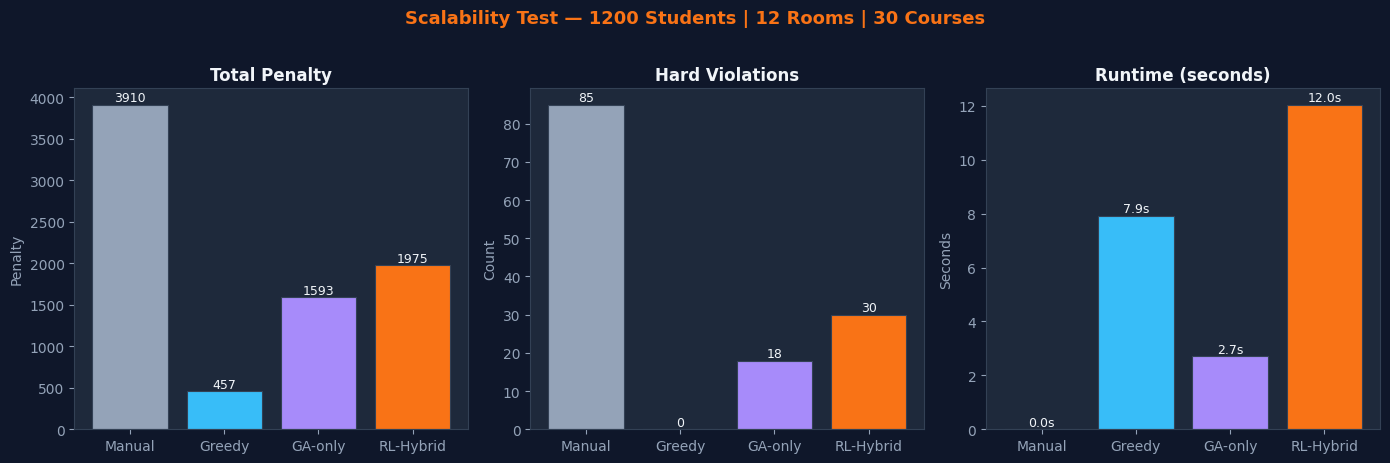


✅ Scalability chart saved → /content/drive/MyDrive/RL_Timetable/results/scalability_test.png

✅ System handles full scale (1200 students, 12 rooms) successfully.


In [14]:
import time

print(f"   Scale: {NUM_STUDENTS} students | {len(COURSES)} courses | {len(ROOMS)} rooms | {len(TIME_SLOTS)} slots")
print("=" * 60)

t0 = time.time()
sc_manual = manual_scheduler()
t_manual = time.time() - t0
p_manual = evaluate_schedule(sc_manual)
hv_manual = count_hard_violations(sc_manual)
print(f"  Manual    → Penalty: {p_manual:7d} | Hard: {hv_manual:4d} | Time: {t_manual:.3f}s")

t0 = time.time()
sc_greedy = greedy_scheduler()
t_greedy = time.time() - t0
p_greedy = evaluate_schedule(sc_greedy)
hv_greedy = count_hard_violations(sc_greedy)
print(f"  Greedy    → Penalty: {p_greedy:7d} | Hard: {hv_greedy:4d} | Time: {t_greedy:.3f}s")

t0 = time.time()
sc_ga, _ = ga_scheduler(pop_size=20, generations=30, verbose=False)
t_ga = time.time() - t0
p_ga = evaluate_schedule(sc_ga)
hv_ga = count_hard_violations(sc_ga)
print(f"  GA-only   → Penalty: {p_ga:7d} | Hard: {hv_ga:4d} | Time: {t_ga:.3f}s")

t0 = time.time()
sc_seed, _ = ga_scheduler(pop_size=20, generations=20, verbose=False)
env_scale = TimetableEnv(sc_seed, max_steps=30)
sc_rl, _ = train_dqn(env_scale, episodes=10, checkpoint_every=999, verbose=False)
t_rl = time.time() - t0
p_rl = evaluate_schedule(sc_rl)
hv_rl = count_hard_violations(sc_rl)
print(f"  RL-Hybrid → Penalty: {p_rl:7d} | Hard: {hv_rl:4d} | Time: {t_rl:.3f}s")

print("\nScalability Summary:")

scale_results = [
    ("Manual",    p_manual, hv_manual, t_manual),
    ("Greedy",    p_greedy, hv_greedy, t_greedy),
    ("GA-only",   p_ga,     hv_ga,     t_ga),
    ("RL-Hybrid", p_rl,     hv_rl,     t_rl),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor('#0f172a')
methods = [r[0] for r in scale_results]
colors  = ['#94a3b8', '#38bdf8', '#a78bfa', '#f97316']

for ax in axes:
    ax.set_facecolor('#1e293b')
    ax.tick_params(colors='#94a3b8')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')

# Penalty
axes[0].bar(methods, [r[1] for r in scale_results], color=colors, edgecolor='#334155', linewidth=0.8)
axes[0].set_title('Total Penalty', color='#f1f5f9', fontweight='bold')
axes[0].set_ylabel('Penalty', color='#94a3b8')
for i, v in enumerate([r[1] for r in scale_results]):
    axes[0].text(i, v + max([r[1] for r in scale_results])*0.01, str(v), ha='center', color='#f1f5f9', fontsize=9)

# Hard violations
axes[1].bar(methods, [r[2] for r in scale_results], color=colors, edgecolor='#334155', linewidth=0.8)
axes[1].set_title('Hard Violations', color='#f1f5f9', fontweight='bold')
axes[1].set_ylabel('Count', color='#94a3b8')
for i, v in enumerate([r[2] for r in scale_results]):
    axes[1].text(i, v + max([r[2] for r in scale_results])*0.01 if max([r[2] for r in scale_results]) > 0 else 0.1, str(v), ha='center', color='#f1f5f9', fontsize=9)

# Runtime
axes[2].bar(methods, [r[3] for r in scale_results], color=colors, edgecolor='#334155', linewidth=0.8)
axes[2].set_title('Runtime (seconds)', color='#f1f5f9', fontweight='bold')
axes[2].set_ylabel('Seconds', color='#94a3b8')
for i, v in enumerate([r[3] for r in scale_results]):
    axes[2].text(i, v + max([r[3] for r in scale_results])*0.01, f'{v:.1f}s', ha='center', color='#f1f5f9', fontsize=9)

plt.suptitle(f'Scalability Test — {NUM_STUDENTS} Students | {len(ROOMS)} Rooms | {len(COURSES)} Courses',
             fontsize=13, fontweight='bold', color='#f97316', y=1.02)
plt.tight_layout()
scale_path = os.path.join(RESULTS_DIR, 'scalability_test.png')
fig.savefig(scale_path, dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f"\n✅ Scalability chart saved → {scale_path}")
print("\n✅ System handles full scale (1200 students, 12 rooms) successfully.")


## Cell 14 — Analytics: Training Curves, Comparison, Heatmap, Conflict Report

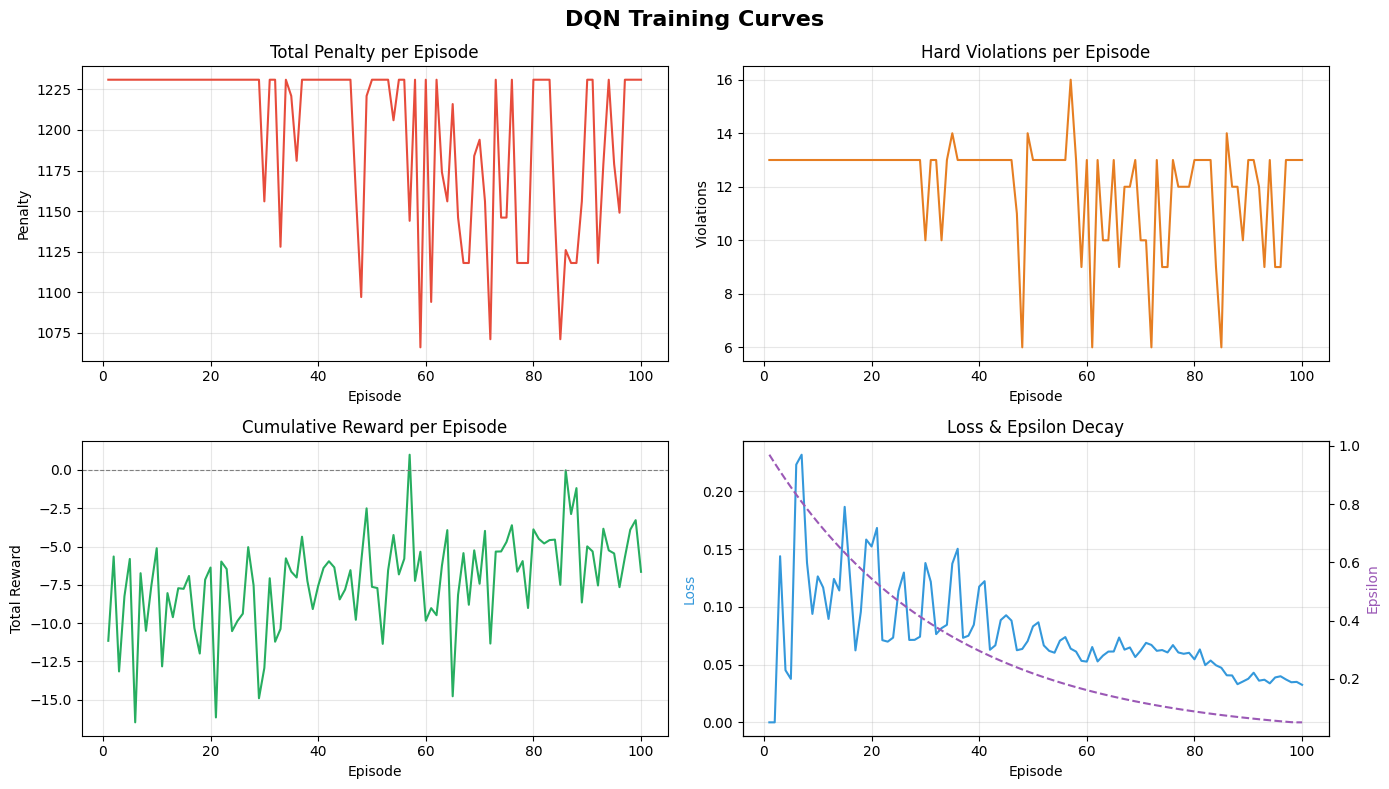

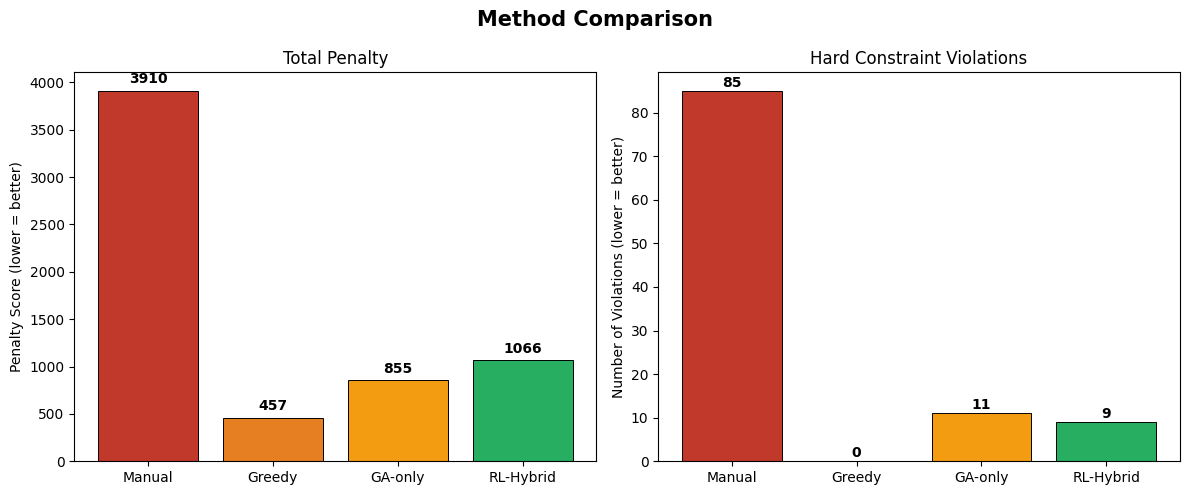

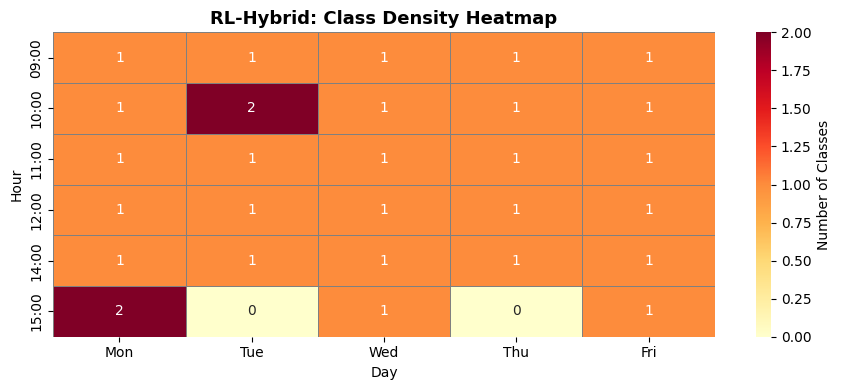

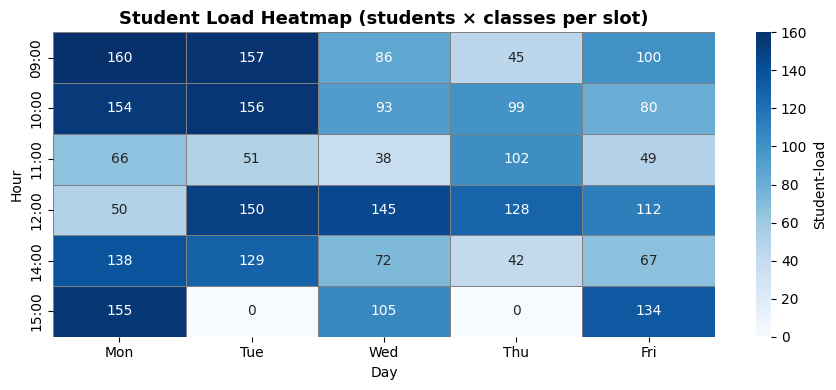


📋 Conflict report: 9 issues found
         Type Severity  Count
Room Overflow     HARD      2
Student Clash     HARD      7


In [15]:
def plot_training_curves(metrics, save_dir):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("DQN Training Curves", fontsize=16, fontweight='bold')

    eps = metrics["episode"]

    axes[0,0].plot(eps, metrics["penalty"], color='#e74c3c', linewidth=1.5)
    axes[0,0].set_title("Total Penalty per Episode")
    axes[0,0].set_xlabel("Episode"); axes[0,0].set_ylabel("Penalty")
    axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(eps, metrics["hard_violations"], color='#e67e22', linewidth=1.5)
    axes[0,1].set_title("Hard Violations per Episode")
    axes[0,1].set_xlabel("Episode"); axes[0,1].set_ylabel("Violations")
    axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(eps, metrics["reward_sum"], color='#27ae60', linewidth=1.5)
    axes[1,0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1,0].set_title("Cumulative Reward per Episode")
    axes[1,0].set_xlabel("Episode"); axes[1,0].set_ylabel("Total Reward")
    axes[1,0].grid(alpha=0.3)

    ax2 = axes[1,1].twinx()
    axes[1,1].plot(eps, metrics["loss"],    color='#3498db', linewidth=1.5, label="Loss")
    ax2.plot(eps, metrics["epsilon"], color='#9b59b6', linewidth=1.5, linestyle='--', label="Epsilon")
    axes[1,1].set_title("Loss & Epsilon Decay")
    axes[1,1].set_xlabel("Episode")
    axes[1,1].set_ylabel("Loss",    color='#3498db')
    ax2.set_ylabel("Epsilon", color='#9b59b6')
    axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(save_dir, "training_curves.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

def plot_comparison(all_results, save_dir):
    methods  = list(all_results.keys())
    penalties = [all_results[m]["penalty"] for m in methods]
    hard_vs   = [all_results[m]["hard_v"]  for m in methods]

    colors = ['#c0392b','#e67e22','#f39c12','#27ae60']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Method Comparison", fontsize=15, fontweight='bold')

    bars = axes[0].bar(methods, penalties, color=colors, edgecolor='black', linewidth=0.7)
    axes[0].set_title("Total Penalty")
    axes[0].set_ylabel("Penalty Score (lower = better)")
    for bar, val in zip(bars, penalties):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

    bars2 = axes[1].bar(methods, hard_vs, color=colors, edgecolor='black', linewidth=0.7)
    axes[1].set_title("Hard Constraint Violations")
    axes[1].set_ylabel("Number of Violations (lower = better)")
    for bar, val in zip(bars2, hard_vs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    path = os.path.join(save_dir, "comparison_chart.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

def build_density_heatmap(schedule, title="Class Density Heatmap"):
    """Shows number of classes scheduled per (Day, Hour) cell."""
    grid = pd.DataFrame(0, index=HOURS, columns=DAYS)
    for c, a in schedule.items():
        day, hour = a["slot"].split("-")
        grid.loc[hour, day] += 1

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(grid, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, linecolor='gray', ax=ax,
                cbar_kws={'label': 'Number of Classes'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Day")
    ax.set_ylabel("Hour")
    plt.tight_layout()
    return fig

def build_student_density_heatmap(schedule):
    """Shows total student-hours per (Day, Hour) cell — class density weighted by enrolment."""
    grid = pd.DataFrame(0, index=HOURS, columns=DAYS)
    for c, a in schedule.items():
        day, hour = a["slot"].split("-")
        grid.loc[hour, day] += course_data[c]["size"]

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(grid, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, linecolor='gray', ax=ax,
                cbar_kws={'label': 'Student-load'})
    ax.set_title("Student Load Heatmap (students × classes per slot)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Day")
    ax.set_ylabel("Hour")
    plt.tight_layout()
    return fig

def build_conflict_report(schedule):
    """Returns a DataFrame listing every conflict found in the schedule."""
    conflicts = []
    teacher_slots = defaultdict(list)
    room_slots    = defaultdict(list)
    student_slots = defaultdict(list)

    for c, a in schedule.items():
        slot, room = a["slot"], a["room"]
        teacher = course_data[c]["teacher"]

        # Room overflow
        if course_data[c]["size"] > ROOMS[room]:
            conflicts.append({"Type": "Room Overflow", "Course": c, "Detail":
                f"{course_data[c]['size']} students in room {room} (cap {ROOMS[room]})",
                "Severity": "HARD"})

        # Teacher clash
        if slot in teacher_slots[teacher]:
            conflicts.append({"Type": "Teacher Clash", "Course": c, "Detail":
                f"Teacher {teacher} double-booked at {slot}", "Severity": "HARD"})
        teacher_slots[teacher].append(slot)

        # Room clash
        key = (room, slot)
        if key in room_slots:
            conflicts.append({"Type": "Room Clash", "Course": c, "Detail":
                f"Room {room} double-booked at {slot} with {room_slots[key]}", "Severity": "HARD"})
        room_slots[key] = c

        # Student clash
        for s in course_data[c]["students"]:
            if slot in student_slots[s]:
                conflicts.append({"Type": "Student Clash", "Course": c, "Detail":
                    f"Student {s} has two classes at {slot}", "Severity": "HARD"})
            student_slots[s].append(slot)

    df = pd.DataFrame(conflicts) if conflicts else pd.DataFrame(
        columns=["Type","Course","Detail","Severity"])
    return df

fig_training = plot_training_curves(metrics, RESULTS_DIR)
fig_compare  = plot_comparison(all_results, RESULTS_DIR)

fig_class_heat = build_density_heatmap(rl_schedule, "RL-Hybrid: Class Density Heatmap")
fig_class_heat.savefig(os.path.join(RESULTS_DIR, "class_density_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

fig_student_heat = build_student_density_heatmap(rl_schedule)
fig_student_heat.savefig(os.path.join(RESULTS_DIR, "student_density_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

conflict_df = build_conflict_report(rl_schedule)
conflict_df.to_csv(os.path.join(RESULTS_DIR, "conflict_report.csv"), index=False)
print(f"\n📋 Conflict report: {len(conflict_df)} issues found")
if len(conflict_df) > 0:
    print(conflict_df.groupby(["Type","Severity"]).size().reset_index(name="Count").to_string(index=False))
else:
    print("  ✅ No hard conflicts!")

## Cell 15 — Gradio Web Application (Full UI)

In [16]:
USER_TEACHER_PREFS = {t: list(slots) for t, slots in TEACHER_PREFS.items()}
USER_ROOMS         = dict(ROOMS)
USER_COURSE_DATA   = {c: dict(v) for c, v in course_data.items()}

LIVE_SCHEDULE = {"sched": None, "metrics": None, "comparison": None}

_SCHED_COLS    = ["Course","Teacher","Day","Hour","Room","Enrolled","Room Cap.","Overflow"]
_CONFLICT_COLS = ["Type", "Detail"]
_STUDENT_COLS  = ["Course","Teacher","Day","Hour","Room"]
_NO_RUN_MSG    = "⚠️ **No schedule yet.** Go to ⚙️ Custom Run and press **▶ Run Custom Scheduler** first."

def format_schedule_df(schedule, cdata=None, rooms=None):
    if cdata is None: cdata = USER_COURSE_DATA
    if rooms is None: rooms = USER_ROOMS
    rows = []
    for c in COURSES:
        if c not in schedule: continue
        a = schedule[c]
        rows.append({
            "Course":    c,
            "Teacher":   cdata[c]["teacher"],
            "Day":       a["slot"].split("-")[0],
            "Hour":      a["slot"].split("-")[1],
            "Room":      a["room"],
            "Enrolled":  cdata[c]["size"],
            "Room Cap.": rooms.get(a["room"], "?"),
            "Overflow":  "⚠ WARN" if cdata[c]["size"] > rooms.get(a["room"], 0) else "✓ OK"
        })
    return pd.DataFrame(rows)

def _empty(cols):
    return pd.DataFrame(columns=cols)

def _prefs_table():
    return pd.DataFrame([
        {"Teacher": t,
         "Preferred Slots": ", ".join(sorted(USER_TEACHER_PREFS.get(t, []))),
         "# Slots": len(USER_TEACHER_PREFS.get(t, []))}
        for t in TEACHERS
    ])

def run_dqn_from_checkpoint(env, episodes, batch_size=128, gamma=0.95,
                             lr=1e-4, eps_start=0.2, eps_end=0.05,
                             eps_decay=0.97, target_update=5,
                             checkpoint_every=10):
    import torch
    import torch.nn as nn
    import torch.optim as optim

    state_dim = 4
    n_actions = env.n_actions
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model  = DuelingDQN(state_dim, n_actions).to(device)
    target = DuelingDQN(state_dim, n_actions).to(device)

    model_loaded = False
    if os.path.exists(MODEL_PATH):
        try:
            state_dict = torch.load(MODEL_PATH, map_location=device)
            model.load_state_dict(state_dict)
            model_loaded = True
        except Exception as e:
            print(f"⚠️ Could not load weights ({e}) — starting from scratch instead")
    else:
        print(f"⚠️ No saved model found at {MODEL_PATH} — starting from scratch")

    target.load_state_dict(model.state_dict())
    target.eval()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.SmoothL1Loss()
    buffer    = ReplayBuffer(capacity=15000)

    # If weights were loaded, start with low epsilon (exploit knowledge)
    # If not, start high so it can explore (same as original training)
    eps = eps_start if model_loaded else 1.0

    metrics = {
        "episode": [], "penalty": [], "hard_violations": [],
        "reward_sum": [], "epsilon": [], "loss": [],
    }

    global_best_penalty  = evaluate_schedule(env.base_schedule)
    global_best_schedule = copy.deepcopy(env.base_schedule)

    for ep in range(1, episodes + 1):
        state     = env.reset()
        ep_reward = 0.0
        ep_loss   = []

        for _ in range(env.max_steps):
            if random.random() < eps:
                action = random.randint(0, n_actions - 1)
            else:
                with torch.no_grad():
                    q_vals = model(torch.tensor(state).float().unsqueeze(0).to(device))
                    action = q_vals.argmax(dim=1).item()

            next_state, reward, done = env.step(action)
            buffer.push(state, action, reward, next_state, done)
            state      = next_state
            ep_reward += reward

            if len(buffer) >= batch_size:
                s, a, r, ns, d = buffer.sample(batch_size)
                s, a, r, ns, d = s.to(device), a.to(device), r.to(device), ns.to(device), d.to(device)

                q_pred = model(s).gather(1, a.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_actions = model(ns).argmax(1)
                    q_next = target(ns).gather(1, next_actions.unsqueeze(1)).squeeze(1)
                    q_target = r + gamma * q_next * (1 - d)

                loss = loss_fn(q_pred, q_target)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                ep_loss.append(loss.item())

            if done:
                break

        ep_penalty = evaluate_schedule(env.best_schedule)
        if ep_penalty < global_best_penalty:
            global_best_penalty  = ep_penalty
            global_best_schedule = copy.deepcopy(env.best_schedule)

        eps = max(eps_end, eps * eps_decay)

        if ep % target_update == 0:
            target.load_state_dict(model.state_dict())

        metrics["episode"].append(ep)
        metrics["penalty"].append(ep_penalty)
        metrics["hard_violations"].append(count_hard_violations(env.best_schedule))
        metrics["reward_sum"].append(ep_reward)
        metrics["epsilon"].append(eps)
        metrics["loss"].append(np.mean(ep_loss) if ep_loss else 0.0)

        if ep % max(1, episodes // 5) == 0 or ep == 1:
            hv = count_hard_violations(env.best_schedule)
            print(f"  Ep {ep:4d}/{episodes} | Penalty: {ep_penalty:6d} | Hard: {hv} | ε: {eps:.3f}")

    # Save the updated weights back so next run benefits too
    torch.save(model.state_dict(), MODEL_PATH)

    return global_best_schedule, metrics

# Tab 1 — Schedule Viewer

def view_schedule(show_conflicts_only):
    if LIVE_SCHEDULE["sched"] is None:
        return _empty(_SCHED_COLS), _NO_RUN_MSG, _empty(_CONFLICT_COLS)
    sched = LIVE_SCHEDULE["sched"]
    df = format_schedule_df(sched)
    if show_conflicts_only:
        df = df[df["Overflow"].str.contains("WARN")]
    penalty, bd = evaluate_schedule(sched, detailed=True)
    hv = count_hard_violations(sched)
    summary = (
        f"### 📊 Schedule Report\n\n"
        f"| Metric | Value |\n|---|---|\n"
        f"| **Total Penalty** | `{penalty}` |\n"
        f"| **Hard Violations** | `{hv}` |\n"
        f"| Room Overflow | `{bd.get('room_overflow',0)}` |\n"
        f"| Teacher Clash | `{bd.get('teacher_clash',0)}` |\n"
        f"| Room Clash | `{bd.get('room_clash',0)}` |\n"
        f"| Student Clash | `{bd.get('student_clash',0)}` |\n"
        f"| Evening Penalty | `{bd.get('evening_penalty',0)}` |\n"
        f"| Teacher Pref | `{bd.get('teacher_pref',0)}` |\n"
        f"| Overloaded Days | `{bd.get('overloaded_day',0)}` |"
    )
    conflict_report = build_conflict_report(sched)
    return df, summary, conflict_report

# Tab 2 — Density Heatmap

def view_heatmap(hmap_type):
    if LIVE_SCHEDULE["sched"] is None:
        return None
    sched = LIVE_SCHEDULE["sched"]
    if hmap_type == "Class Density":
        return build_density_heatmap(sched, "Custom Run: Class Density")
    else:
        return build_student_density_heatmap(sched)

# Tab 3 — Training Curves

def view_training_curves():
    if LIVE_SCHEDULE["metrics"] is None:
        return None
    m = LIVE_SCHEDULE["metrics"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor('#0f172a')
    for ax in axes:
        ax.set_facecolor('#1e293b')
        ax.tick_params(colors='#94a3b8')
        ax.xaxis.label.set_color('#94a3b8')
        ax.yaxis.label.set_color('#94a3b8')
        for spine in ax.spines.values():
            spine.set_edgecolor('#334155')
    axes[0].plot(m["episode"], m["penalty"],        color='#f97316', lw=2,   label="Penalty")
    axes[0].plot(m["episode"], m["hard_violations"], color='#fb923c', lw=1.5, linestyle='--', label="Hard violations")
    axes[0].set_title("Penalty & Hard Violations", color='#f1f5f9', fontsize=12, fontweight='bold')
    axes[0].legend(framealpha=0.2, labelcolor='#f1f5f9')
    axes[0].grid(alpha=0.15, color='#475569')
    axes[1].plot(m["episode"], m["reward_sum"], color='#34d399', lw=2,   label="Reward")
    axes[1].plot(m["episode"], m["loss"],       color='#60a5fa', lw=1.5, linestyle='--', label="Loss")
    axes[1].axhline(0, color='#64748b', linestyle='--', linewidth=0.8)
    axes[1].set_title("Reward & Loss", color='#f1f5f9', fontsize=12, fontweight='bold')
    axes[1].legend(framealpha=0.2, labelcolor='#f1f5f9')
    axes[1].grid(alpha=0.15, color='#475569')
    fig.suptitle("DQN Fine-tuning Curves — Custom Run", fontsize=13, fontweight='bold', color='#f97316')
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig

# Tab 4 — Teacher Preferences

def load_teacher_prefs(teacher):
    return USER_TEACHER_PREFS.get(teacher, [])

def save_teacher_prefs(teacher, selected_slots):
    global USER_TEACHER_PREFS
    USER_TEACHER_PREFS[teacher] = list(selected_slots)
    msg = (
        f"✅ **Saved** `{len(selected_slots)}` preferred slot(s) for **{teacher}**\n\n"
        + (f"`{', '.join(sorted(selected_slots))}`" if selected_slots else "_No slots — any slot accepted._")
    )
    return msg, _prefs_table()

def reset_teacher_prefs():
    global USER_TEACHER_PREFS
    USER_TEACHER_PREFS = {t: list(slots) for t, slots in TEACHER_PREFS.items()}
    return "🔄 Reset to defaults.", _prefs_table()

# Tab 5 — Courses & Rooms

def get_course_table():
    return pd.DataFrame([{"Course": c, "Teacher": USER_COURSE_DATA[c]["teacher"],
                           "Enrolled": USER_COURSE_DATA[c]["size"]} for c in COURSES])

def update_course(course, new_teacher, new_size):
    global USER_COURSE_DATA
    USER_COURSE_DATA[course]["teacher"] = new_teacher
    USER_COURSE_DATA[course]["size"]    = int(new_size)
    return f"✅ **{course}** → Teacher: `{new_teacher}`, Enrolled: `{int(new_size)}`", get_course_table()

def get_room_table():
    return pd.DataFrame([{"Room": r, "Capacity": c} for r, c in USER_ROOMS.items()])

def update_room(room, new_cap):
    global USER_ROOMS
    USER_ROOMS[room] = int(new_cap)
    return f"✅ **{room}** capacity → `{int(new_cap)}`", get_room_table()

# Tab 6 — Custom Run  (uses YOUR trained model)

def run_custom(ga_pop, ga_gens, dqn_eps, dqn_steps, evening_penalty_w, overload_penalty_w, teacher_pref_w):
    global PENALTY_EVENING, PENALTY_3_CLASSES_DAY, PENALTY_TEACHER_PREF
    global TEACHER_PREFS, course_data, ROOMS, LIVE_SCHEDULE

    PENALTY_EVENING       = int(evening_penalty_w)
    PENALTY_3_CLASSES_DAY = int(overload_penalty_w)
    PENALTY_TEACHER_PREF  = int(teacher_pref_w)
    TEACHER_PREFS = {t: list(s) for t, s in USER_TEACHER_PREFS.items()}
    course_data   = {c: dict(v) for c, v in USER_COURSE_DATA.items()}
    ROOMS         = dict(USER_ROOMS)

    model_status = "✅ **Your trained model weights loaded**" if os.path.exists(MODEL_PATH) \
                   else "⚠️ **No saved model found — training from scratch**"

    log = [
        f"🤖 {model_status}",
        "⚙️ **Running with your settings…**",
        f"- Evening penalty `{PENALTY_EVENING}` | Overload `{PENALTY_3_CLASSES_DAY}` | Teacher pref `{PENALTY_TEACHER_PREF}`",
        f"- GA: pop=`{int(ga_pop)}`, gens=`{int(ga_gens)}` | DQN: eps=`{int(dqn_eps)}`, steps=`{int(dqn_steps)}`",
    ]

    log.append("\n📊 **Step 1 — Running all 4 algorithms for comparison…**")

    manual_sched = manual_scheduler()
    p_manual = evaluate_schedule(manual_sched)
    hv_manual = count_hard_violations(manual_sched)
    log.append(f"- Manual: penalty `{p_manual}` | hard violations `{hv_manual}`")

    greedy_sched = greedy_scheduler()
    p_greedy = evaluate_schedule(greedy_sched)
    hv_greedy = count_hard_violations(greedy_sched)
    log.append(f"- Greedy: penalty `{p_greedy}` | hard violations `{hv_greedy}`")

    ga_only_sched, _ = ga_scheduler(pop_size=int(ga_pop), generations=int(ga_gens), verbose=False)
    p_ga = evaluate_schedule(ga_only_sched)
    hv_ga = count_hard_violations(ga_only_sched)
    log.append(f"- GA-only: penalty `{p_ga}` | hard violations `{hv_ga}`")

    log.append("\n🧬 **Step 2 — GA generates a fresh seed for DQN…**")
    seed_sched, _ = ga_scheduler(pop_size=int(ga_pop), generations=int(ga_gens), verbose=False)
    log.append(f"- GA seed penalty: `{evaluate_schedule(seed_sched)}`")

    log.append("\n🧠 **Step 3 — Your trained DQN refines the schedule…**")
    env = TimetableEnv(seed_sched, max_steps=int(dqn_steps))
    best_sched, m2 = run_dqn_from_checkpoint(env, episodes=int(dqn_eps))

    p, bd = evaluate_schedule(best_sched, detailed=True)
    hv = count_hard_violations(best_sched)
    log.append(f"- RL-Hybrid: penalty `{p}` | hard violations `{hv}`")

    LIVE_SCHEDULE["sched"]   = best_sched
    LIVE_SCHEDULE["metrics"] = m2
    LIVE_SCHEDULE["comparison"] = {
        "Manual":    {"penalty": p_manual,  "hard_v": hv_manual,  "sched": manual_sched,   "bd": {}},
        "Greedy":    {"penalty": p_greedy,  "hard_v": hv_greedy,  "sched": greedy_sched,   "bd": {}},
        "GA-only":   {"penalty": p_ga,      "hard_v": hv_ga,      "sched": ga_only_sched,  "bd": {}},
        "RL-Hybrid": {"penalty": p,         "hard_v": hv,         "sched": best_sched,     "bd": bd},
    }

    log.append(f"\n✅ **Done!** Penalty: `{p}` | Hard violations: `{hv}`")
    log.append(
        f"- Room overflow `{bd.get('room_overflow',0)}` | Teacher clash `{bd.get('teacher_clash',0)}` | "
        f"Room clash `{bd.get('room_clash',0)}` | Student clash `{bd.get('student_clash',0)}`"
    )
    log.append("\n✔️ **All tabs updated — Comparison chart now shows all 4 methods.**")
    df = format_schedule_df(best_sched, cdata=course_data, rooms=ROOMS)
    return df, "\n\n".join(log)

# Tab 7 — Student Lookup

def lookup_student(student_id):
    if LIVE_SCHEDULE["sched"] is None:
        return _NO_RUN_MSG, _empty(_STUDENT_COLS)
    sched = LIVE_SCHEDULE["sched"]
    sid = student_id.strip()
    if sid not in STUDENTS:
        return f"❌ Student **{sid}** not found. Valid range: S1–S{NUM_STUDENTS}", _empty(_STUDENT_COLS)
    rows = []
    for c, a in sched.items():
        if sid in course_data[c]["students"]:
            rows.append({"Course": c, "Teacher": course_data[c]["teacher"],
                         "Day": a["slot"].split("-")[0], "Hour": a["slot"].split("-")[1], "Room": a["room"]})
    if not rows:
        return f"ℹ️ Student **{sid}** is not enrolled in any course.", _empty(_STUDENT_COLS)
    df = pd.DataFrame(rows).sort_values(["Day","Hour"])
    slots_seen, clashes = [], 0
    for _, row in df.iterrows():
        slot = f"{row['Day']}-{row['Hour']}"
        if slot in slots_seen: clashes += 1
        slots_seen.append(slot)
    clash_msg = f"  ⚠️ **{clashes} time clash(es) detected!**" if clashes else "  ✅ No time clashes."
    return f"Student **{sid}** enrolled in **{len(rows)}** course(s).{clash_msg}", df

# Tab 8 — Room Availability

def show_room_availability(selected_room):
    if LIVE_SCHEDULE["sched"] is None:
        return None, _NO_RUN_MSG
    sched = LIVE_SCHEDULE["sched"]
    booked = {a["slot"]: c for c, a in sched.items() if a["room"] == selected_room}
    grid_data = []
    for hour in HOURS:
        row = {"Hour": hour}
        for day in DAYS:
            row[day] = booked.get(f"{day}-{hour}", "FREE")
        grid_data.append(row)
    df = pd.DataFrame(grid_data).set_index("Hour")
    fig, ax = plt.subplots(figsize=(11, 4))
    fig.patch.set_facecolor('#0f172a')
    ax.set_facecolor('#0f172a'); ax.axis('off')
    table = ax.table(cellText=df.values, rowLabels=df.index, colLabels=df.columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.3, 1.9)
    cap = USER_ROOMS.get(selected_room, ROOMS.get(selected_room, "?"))
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.5); cell.set_edgecolor('#334155')
        if row == 0 or col == -1:
            cell.set_facecolor('#1e3a5f'); cell.set_text_props(color='#93c5fd', fontweight='bold')
        elif cell.get_text().get_text() == "FREE":
            cell.set_facecolor('#064e3b'); cell.set_text_props(color='#6ee7b7')
        else:
            cell.set_facecolor('#1e293b'); cell.set_text_props(color='#f97316')
    ax.set_title(f"Room {selected_room}  ·  Capacity {cap}  ·  Custom Run",
                 fontsize=12, fontweight='bold', color='#f1f5f9', pad=14)
    plt.tight_layout()
    booked_count = len(booked)
    pct = 100 * booked_count // len(TIME_SLOTS)
    info = (f"🏫 Room **{selected_room}** &nbsp;|&nbsp; Capacity: **{cap}** &nbsp;|&nbsp; "
            f"Booked: **{booked_count}/{len(TIME_SLOTS)}** slots &nbsp;|&nbsp; Utilisation: **{pct}%**")
    return fig, info

# Tab 0 — Comparison Chart (Manual vs Greedy vs GA-only vs RL-Hybrid)

def view_comparison():
    """Show the 4-method comparison chart from the last full pipeline run."""
    import os, pickle
    try:
        ALL_RESULTS_PATH = os.path.join(DRIVE_DIR, 'all_results.pkl')
        if not os.path.exists(ALL_RESULTS_PATH):
            fig, ax = plt.subplots(figsize=(8, 3))
            fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#0f172a'); ax.axis('off')
            ax.text(0.5, 0.5, "Run the full pipeline (Cell 12) first to generate comparison data.",
                    ha='center', va='center', color='#94a3b8', fontsize=12, transform=ax.transAxes)
            return fig
        with open(ALL_RESULTS_PATH, 'rb') as f:
            ar = pickle.load(f)
    except Exception:
        ar = None

    # Prefer live comparison data (from Custom Run) — always up to date
    if LIVE_SCHEDULE.get("comparison") is not None:
        ar = LIVE_SCHEDULE["comparison"]
    elif ar is None:
        fig, ax = plt.subplots(figsize=(8, 3))
        fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#0f172a'); ax.axis('off')
        ax.text(0.5, 0.5, "Run the Custom Run tab first to populate comparison data.",
                ha='center', va='center', color='#94a3b8', fontsize=12, transform=ax.transAxes)
        return fig

    methods = list(ar.keys())
    penalties = [ar[m]["penalty"] for m in methods]
    hard_vs   = [ar[m]["hard_v"]  for m in methods]
    colors    = ['#94a3b8', '#38bdf8', '#a78bfa', '#f97316']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#0f172a')
    for ax in axes:
        ax.set_facecolor('#1e293b')
        ax.tick_params(colors='#94a3b8')
        ax.xaxis.label.set_color('#94a3b8')
        ax.yaxis.label.set_color('#94a3b8')
        for spine in ax.spines.values():
            spine.set_edgecolor('#334155')

    bars0 = axes[0].bar(methods, penalties, color=colors, edgecolor='#334155', linewidth=0.8, width=0.55)
    axes[0].set_title("Total Penalty Score", color='#f1f5f9', fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Penalty (lower = better)", color='#94a3b8')
    for bar, val in zip(bars0, penalties):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(penalties)*0.01,
                     str(val), ha='center', va='bottom', color='#f1f5f9', fontsize=10, fontweight='bold')

    bars1 = axes[1].bar(methods, hard_vs, color=colors, edgecolor='#334155', linewidth=0.8, width=0.55)
    axes[1].set_title("Hard Constraint Violations", color='#f1f5f9', fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Violations (lower = better)", color='#94a3b8')
    mx = max(hard_vs) if max(hard_vs) > 0 else 1
    for bar, val in zip(bars1, hard_vs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + mx*0.01,
                     str(val), ha='center', va='bottom', color='#f1f5f9', fontsize=10, fontweight='bold')

    fig.suptitle("Comparison: Manual vs Greedy vs GA-only vs RL-Hybrid",
                 fontsize=12, fontweight='bold', color='#f97316')
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig

# CSS
css = """
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=DM+Mono:wght@400;500&family=Sora:wght@600;700&display=swap');
:root {
    --bg:#0a0f1e; --surface:#111827; --surface2:#1e293b; --border:#1f2d45;
    --accent:#f97316; --accent2:#fb923c; --blue:#3b82f6; --green:#34d399;
    --text:#e2e8f0; --muted:#64748b; --radius:12px;
    --font:'DM Sans',sans-serif; --mono:'DM Mono',monospace; --display:'Sora',sans-serif;
}
body,.gradio-container{background:var(--bg)!important;color:var(--text)!important;font-family:var(--font)!important;font-size:14px!important;}
.app-header{background:linear-gradient(135deg,#0f172a 0%,#1a2540 50%,#0f172a 100%);border-bottom:1px solid var(--border);border-radius:var(--radius);padding:28px 32px 20px;margin-bottom:8px;position:relative;overflow:hidden;}
.app-header::before{content:'';position:absolute;inset:0;background:radial-gradient(ellipse 60% 80% at 80% 50%,rgba(249,115,22,.07) 0%,transparent 70%);pointer-events:none;}
.app-header h1{font-family:var(--display)!important;font-size:1.75rem!important;font-weight:700!important;color:#f1f5f9!important;margin:0 0 4px!important;letter-spacing:-.5px;}
.app-header p{color:var(--muted)!important;font-size:.85rem!important;margin:0!important;}
.pill{display:inline-block;background:rgba(249,115,22,.15);color:var(--accent);border:1px solid rgba(249,115,22,.3);border-radius:99px;padding:2px 10px;font-size:.75rem;font-weight:600;font-family:var(--mono);margin-right:8px;}
.run-banner{background:linear-gradient(90deg,rgba(249,115,22,.12),rgba(249,115,22,.04));border:1px solid rgba(249,115,22,.3);border-radius:var(--radius);padding:14px 20px;margin-bottom:18px;font-size:.85rem;color:#fed7aa;}
.model-banner{background:linear-gradient(90deg,rgba(52,211,153,.1),rgba(52,211,153,.03));border:1px solid rgba(52,211,153,.3);border-radius:var(--radius);padding:12px 20px;margin-bottom:18px;font-size:.82rem;color:#6ee7b7;}
.tab-nav{background:var(--surface)!important;border-bottom:1px solid var(--border)!important;border-radius:var(--radius) var(--radius) 0 0!important;padding:0 8px!important;}
.tab-nav button{font-family:var(--font)!important;font-size:.8rem!important;font-weight:500!important;color:var(--muted)!important;border:none!important;border-bottom:2px solid transparent!important;background:transparent!important;padding:10px 14px!important;border-radius:0!important;transition:color .2s,border-color .2s;}
.tab-nav button:hover{color:var(--text)!important;}
.tab-nav button.selected{color:var(--accent)!important;border-bottom-color:var(--accent)!important;}
.tabitem{background:var(--surface)!important;border:1px solid var(--border)!important;border-top:none!important;border-radius:0 0 var(--radius) var(--radius)!important;padding:24px!important;}
.tab-subheading{font-size:.8rem!important;color:var(--muted)!important;margin:0 0 16px!important;}
input,textarea,select{background:#0f172a!important;border:1px solid var(--border)!important;color:var(--text)!important;border-radius:8px!important;font-family:var(--font)!important;}
input:focus,textarea:focus{border-color:var(--accent)!important;box-shadow:0 0 0 3px rgba(249,115,22,.15)!important;outline:none!important;}
label,.gr-form label{color:var(--text)!important;font-size:.82rem!important;font-weight:500!important;margin-bottom:4px!important;}
.gr-slider input[type=range]{accent-color:var(--accent)!important;}
input[type=checkbox],input[type=radio]{accent-color:var(--accent)!important;}
button.primary,.gr-button-primary{background:linear-gradient(135deg,var(--accent),#ea580c)!important;color:#fff!important;border:none!important;border-radius:8px!important;font-family:var(--font)!important;font-weight:600!important;font-size:.85rem!important;padding:9px 20px!important;cursor:pointer!important;transition:opacity .2s,transform .1s!important;box-shadow:0 4px 14px rgba(249,115,22,.25)!important;}
button.primary:hover{opacity:.9!important;transform:translateY(-1px)!important;}
button.secondary,.gr-button-secondary{background:var(--surface2)!important;color:var(--text)!important;border:1px solid var(--border)!important;border-radius:8px!important;font-family:var(--font)!important;font-size:.85rem!important;padding:9px 20px!important;cursor:pointer!important;transition:border-color .2s!important;}
button.secondary:hover{border-color:var(--accent)!important;}
.gr-dataframe table{background:#0a0f1e!important;border-collapse:collapse!important;font-family:var(--mono)!important;font-size:.78rem!important;}
.gr-dataframe th{background:var(--surface2)!important;color:var(--accent)!important;font-weight:600!important;font-size:.75rem!important;text-transform:uppercase!important;letter-spacing:.05em!important;border-bottom:1px solid var(--border)!important;padding:8px 12px!important;}
.gr-dataframe td{color:var(--text)!important;border-bottom:1px solid var(--border)!important;padding:7px 12px!important;}
.gr-dataframe tr:hover td{background:var(--surface2)!important;}
.gr-markdown{color:var(--text)!important;}
.gr-markdown h3{font-family:var(--display)!important;color:#f1f5f9!important;font-size:1rem!important;margin-bottom:10px!important;}
.gr-markdown table{width:100%;border-collapse:collapse;font-family:var(--mono);font-size:.8rem;}
.gr-markdown th{background:var(--surface2);color:var(--accent);padding:7px 12px;border:1px solid var(--border);text-align:left;}
.gr-markdown td{padding:6px 12px;border:1px solid var(--border);color:var(--text);}
.gr-markdown code{background:rgba(249,115,22,.12);color:var(--accent2);padding:1px 5px;border-radius:4px;font-family:var(--mono);font-size:.82rem;}
.gr-accordion{background:var(--surface2)!important;border:1px solid var(--border)!important;border-radius:var(--radius)!important;margin-bottom:12px!important;}
.gr-accordion summary{color:var(--text)!important;font-weight:500!important;font-size:.85rem!important;padding:12px 16px!important;}
.divider{border:none;border-top:1px solid var(--border);margin:18px 0;}
"""

# Check at startup whether the trained model exists
_model_exists = os.path.exists(MODEL_PATH)
_model_banner_text = (
    f"🧠 <strong>Trained model found</strong> — <code>best_model.pth</code> will be loaded automatically when you run the scheduler. "
    f"Your DQN picks up exactly where training left off."
) if _model_exists else (
    "⚠️ <strong>No trained model found</strong> at the expected path. "
    "The scheduler will train a fresh DQN from scratch. "
    "Run Cell 12 of your notebook first to generate <code>best_model.pth</code>."
)

# Layout
with gr.Blocks(title="RL Timetable Scheduler", css=css, theme=gr.themes.Base()) as app:

    gr.HTML("""
    <div class="app-header">
      <h1>🎓 Intelligent University Timetable Scheduler</h1>
      <p><span class="pill">CT-469</span><span class="pill">Reinforcement Learning</span>
         GA + Dueling Double DQN &nbsp;·&nbsp; 1 200 students &nbsp;·&nbsp; 30 courses &nbsp;·&nbsp; 12 rooms</p>
    </div>
    """)

    gr.HTML(f'<div class="model-banner">🧠 {_model_banner_text}</div>')

    gr.HTML("""
    <div class="run-banner">
      🚀 <strong>Workflow:</strong> Optionally edit preferences/rooms in the tabs below →
      go to <strong>⚙️ Custom Run</strong> → press <strong>▶ Run</strong> →
      your trained DQN refines the schedule → all tabs update automatically.
    </div>
    """)

    with gr.Tabs():

        with gr.Tab("📊 Comparison"):
            gr.HTML("<p class='tab-subheading'>Side-by-side penalty and hard-violation scores: Manual vs Greedy vs GA-only vs RL-Hybrid. Populated after running Cell 12 or the Custom Run tab.</p>")
            compare_btn  = gr.Button("📊  Show Comparison Chart", variant="primary")
            compare_plot = gr.Plot()
            compare_btn.click(view_comparison, outputs=compare_plot)

        with gr.Tab("📅 Schedule Viewer"):
            gr.HTML("<p class='tab-subheading'>Full timetable from your last run. Filter to highlight rooms where enrolment exceeds capacity.</p>")
            with gr.Row():
                conflict_cb = gr.Checkbox(label="⚠ Show overflowed rows only", value=False, scale=1)
                view_btn    = gr.Button("🔍  Refresh View", variant="primary", scale=1)
            summary_md     = gr.Markdown(value=_NO_RUN_MSG)
            gr.HTML("<hr class='divider'>")
            sched_table    = gr.Dataframe(value=_empty(_SCHED_COLS),    label="📋 Full Schedule",   interactive=False)
            conflict_table = gr.Dataframe(value=_empty(_CONFLICT_COLS), label="⚠ Conflict Report", interactive=False)
            view_btn.click(view_schedule, inputs=[conflict_cb], outputs=[sched_table, summary_md, conflict_table])

        with gr.Tab("🌡 Density Heatmaps"):
            gr.HTML("<p class='tab-subheading'>How classes and student load are spread across the week from your last run.</p>")
            with gr.Row():
                hmap_type = gr.Radio(["Class Density","Student Load"], value="Class Density", label="Heatmap Type", scale=2)
                hmap_btn  = gr.Button("🌡  Generate Heatmap", variant="primary", scale=1)
            hmap_plot = gr.Plot()
            hmap_btn.click(view_heatmap, inputs=[hmap_type], outputs=hmap_plot)

        with gr.Tab("📉 Training Curves"):
            gr.HTML("<p class='tab-subheading'>Your DQN's fine-tuning progress from the last run — penalty should stay low, reward should stay high since the model already knows what to do.</p>")
            curve_btn  = gr.Button("📉  Show Training Curves", variant="primary")
            curve_plot = gr.Plot()
            curve_btn.click(view_training_curves, outputs=curve_plot)

        with gr.Tab("👩‍🏫 Teacher Preferences"):
            gr.HTML("<p class='tab-subheading'>Set preferred time slots per teacher. The DQN already learned the original preferences — changes here will be applied as soft constraints on your next run.</p>")
            with gr.Row():
                teacher_dd = gr.Dropdown(TEACHERS, value=TEACHERS[0], label="Select Teacher", scale=3)
                load_btn   = gr.Button("⬇ Load Preferences", scale=1)
            pref_slots = gr.CheckboxGroup(choices=TIME_SLOTS, label="Preferred Time Slots",
                                          value=list(USER_TEACHER_PREFS.get(TEACHERS[0], [])))
            with gr.Row():
                save_pref_btn  = gr.Button("💾  Save for this Teacher", variant="primary")
                reset_pref_btn = gr.Button("🔄  Reset All to Defaults")
            pref_status = gr.Markdown()
            gr.HTML("<hr class='divider'>")
            pref_table = gr.Dataframe(label="📋 All Teacher Preferences", value=_prefs_table(), interactive=False)
            load_btn.click(load_teacher_prefs,      inputs=[teacher_dd],              outputs=[pref_slots])
            save_pref_btn.click(save_teacher_prefs,  inputs=[teacher_dd, pref_slots], outputs=[pref_status, pref_table])
            reset_pref_btn.click(reset_teacher_prefs,                                 outputs=[pref_status, pref_table])

        with gr.Tab("🏫 Courses & Rooms"):
            gr.HTML("<p class='tab-subheading'>Change teacher assignments, enrolment numbers, and room capacities. Applied on your next run.</p>")
            with gr.Accordion("✏️  Edit a Course", open=True):
                with gr.Row():
                    course_dd2  = gr.Dropdown(COURSES,  value=COURSES[0],  label="Course",           scale=2)
                    teacher_dd2 = gr.Dropdown(TEACHERS, value=TEACHERS[0], label="Assign Teacher",    scale=2)
                    size_slider = gr.Slider(10, 220, value=60, step=5,     label="Enrolled Students", scale=3)
                update_course_btn = gr.Button("💾  Save Course", variant="primary")
                course_status = gr.Markdown()
                course_table  = gr.Dataframe(label="📋 All Courses", value=get_course_table(), interactive=False)
                update_course_btn.click(update_course, inputs=[course_dd2, teacher_dd2, size_slider],
                                        outputs=[course_status, course_table])
            with gr.Accordion("🔧  Edit Room Capacity", open=True):
                with gr.Row():
                    room_dd2   = gr.Dropdown(list(ROOMS.keys()), value="R1", label="Room",       scale=2)
                    cap_slider = gr.Slider(20, 500, value=60, step=10,      label="New Capacity", scale=3)
                update_room_btn = gr.Button("💾  Save Room", variant="primary")
                room_status = gr.Markdown()
                room_table  = gr.Dataframe(label="📋 All Rooms", value=get_room_table(), interactive=False)
                update_room_btn.click(update_room, inputs=[room_dd2, cap_slider],
                                      outputs=[room_status, room_table])

        with gr.Tab("⚙️ Custom Run"):
            gr.HTML("<p class='tab-subheading'>GA builds a seed schedule, then <strong>your trained DQN</strong> refines it. The model weights are loaded from Drive automatically. Results populate all other tabs.</p>")
            with gr.Row():
                with gr.Column():
                    gr.Markdown("**🧬 Genetic Algorithm** *(seed generation)*")
                    ga_pop  = gr.Slider(10, 100, value=40, step=5,  label="Population Size")
                    ga_gens = gr.Slider(10, 200, value=60, step=10, label="Generations")
                with gr.Column():
                    gr.Markdown("**🧠 Your Trained DQN** *(fine-tuning)*")
                    dqn_eps   = gr.Slider(10, 200, value=80, step=10, label="Episodes")
                    dqn_steps = gr.Slider(20, 100, value=60, step=10, label="Steps per Episode")
            gr.HTML("<hr class='divider'>")
            gr.Markdown("**⚖️ Soft-Constraint Penalty Weights**")
            with gr.Row():
                eve_w   = gr.Slider(0, 50, value=5,  step=1, label="Evening Slot Penalty")
                ovl_w   = gr.Slider(0, 50, value=10, step=1, label="3+ Classes/Day Penalty")
                tpref_w = gr.Slider(0, 50, value=8,  step=1, label="Teacher Pref Penalty")
            run_btn = gr.Button("▶  Run Custom Scheduler", variant="primary")
            gr.HTML("<hr class='divider'>")
            custom_log   = gr.Markdown()
            custom_table = gr.Dataframe(value=_empty(_SCHED_COLS),
                                        label="📋 Schedule — appears after run", interactive=False)
            run_btn.click(run_custom,
                          inputs=[ga_pop, ga_gens, dqn_eps, dqn_steps, eve_w, ovl_w, tpref_w],
                          outputs=[custom_table, custom_log])

        with gr.Tab("🎓 Student Lookup"):
            gr.HTML("<p class='tab-subheading'>Enter a student ID to see their timetable and detect clashes. Uses your last run.</p>")
            with gr.Row():
                student_input = gr.Textbox(label="Student ID", placeholder="e.g.  S42", scale=3)
                student_btn   = gr.Button("🔍  Look Up", variant="primary", scale=1)
            student_status = gr.Markdown()
            student_table  = gr.Dataframe(value=_empty(_STUDENT_COLS),
                                          label="🗓 Student Timetable", interactive=False)
            student_btn.click(lookup_student, inputs=[student_input],
                              outputs=[student_status, student_table])

        with gr.Tab("🚪 Room Availability"):
            gr.HTML("<p class='tab-subheading'>Booking grid for any room. Green = free, orange = occupied. Uses your last run.</p>")
            with gr.Row():
                room_sel_dd    = gr.Dropdown(list(ROOMS.keys()), value="R1", label="Room", scale=2)
                room_avail_btn = gr.Button("🚪  Show Availability", variant="primary", scale=1)
            room_avail_info = gr.Markdown()
            room_avail_plot = gr.Plot()
            room_avail_btn.click(show_room_availability, inputs=[room_sel_dd],
                                 outputs=[room_avail_plot, room_avail_info])

    gr.HTML("""
    <div style="text-align:center;padding:18px 0 6px;color:#334155;font-size:.75rem;font-family:'DM Mono',monospace;">
      CT-469 Reinforcement Learning Project &nbsp;·&nbsp; GA + Dueling Double DQN &nbsp;·&nbsp; Built with Gradio
    </div>
    """)


/tmp/ipykernel_8770/510411592.py:513: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="RL Timetable Scheduler", css=css, theme=gr.themes.Base()) as app:
/tmp/ipykernel_8770/510411592.py:513: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="RL Timetable Scheduler", css=css, theme=gr.themes.Base()) as app:


## Cell 16 — Launch App (Colab public URL)

In [17]:
app.launch(share=True, show_error=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3527ff3c2540da8977.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
